# Przewidywanie odejść klientów (Customer Churn) w sektorze telekomunikacyjnym

**Cel biznesowy:** Zbudowanie modelu klasyfikacyjnego, który na podstawie danych historycznych zidentyfikuje klientów o najwyższym ryzyku rezygnacji z usług. Priorytetem projektu jest maksymalizacja wyłapanych uciekinierów (Czułość/Recall), minimalizując tym samym straty finansowe firmy.

## 1. Import bibliotek i wczytanie danych
Używamy standardowego zbioru danych *Telco Customer Churn*.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

# Pobranie danych ze stabilnego repozytorium IBM
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(f"Rozmiar początkowy: {df.shape[0]} wierszy, {df.shape[1]} kolumn.")

Rozmiar początkowy: 7043 wierszy, 21 kolumn.


## 2. Czyszczenie danych
Kolumna `TotalCharges` zawierała ukryte znaki spacji traktowane jako tekst. Wymuszamy konwersję na format numeryczny i usuwamy marginalną liczbę braków danych. Usuwamy również `customerID`, aby zapobiec przeuczeniu modelu (szum informacyjny).

In [16]:
# Konwersja na liczby i usunięcie błędów
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)

print("Dane po czyszczeniu są gotowe do transformacji.")

Dane po czyszczeniu są gotowe do transformacji.


## 3. Kodowanie zmiennych
Algorytmy uczenia maszynowego wymagają danych numerycznych. Zmieniamy naszą kolumnę docelową `Churn` na system binarny (1 - Odszedł, 0 - Został), a pozostałe zmienne tekstowe rozbijamy na flagi zero-jedynkowe, unikając pułapki współliniowości (`drop_first=True`).

In [17]:
# Encoding
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded = df_encoded.astype(float)

# Podział na X i y
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Podział na zbiór treningowy i testowy (75/25)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## 4. Budowa modelu bazowego (Random Forest)
W pierwszej iteracji używamy Lasu Losowego z domyślnymi ustawieniami (próg decyzyjny 50%). Sprawdzimy, gdzie dokładnie myli się ten algorytm.

--- RAPORT BAZOWY ---
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.87      1300
         1.0       0.64      0.48      0.55       458

    accuracy                           0.79      1758
   macro avg       0.73      0.69      0.71      1758
weighted avg       0.78      0.79      0.78      1758



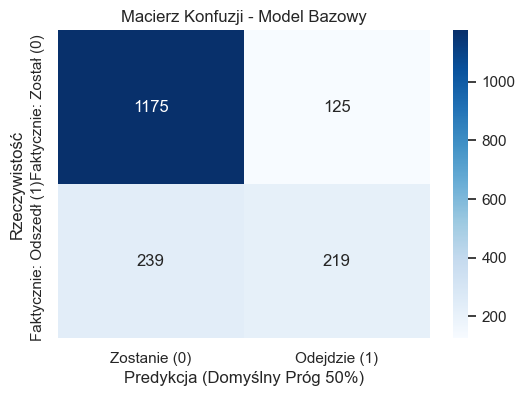

In [18]:
# Trenowanie modelu bazowego
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

prognozy = model_rf.predict(X_test)
print("--- RAPORT BAZOWY ---")
print(classification_report(y_test, prognozy))

# Generujemy niebieską macierz konfuzji
cm_base = confusion_matrix(y_test, prognozy)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Zostanie (0)', 'Odejdzie (1)'], 
            yticklabels=['Faktycznie: Został (0)', 'Faktycznie: Odszedł (1)'])
plt.ylabel('Rzeczywistość')
plt.xlabel('Predykcja (Domyślny Próg 50%)')
plt.title('Macierz Konfuzji - Model Bazowy')
plt.show()

**Wniosek:** Model świetnie wyłapuje osoby zostające, ale przeoczył ponad połowę klientów uciekających (Czułość wynosi zaledwie ok. 48%). Wynika to z niezbalansowania klas w danych.

## 5. Próba naprawy nr 1: Zbalansowanie wag (Class Weights)
Zmuśmy model do zwracania większej uwagi na rzadszą klasę (odchodzących), używając wbudowanego parametru `class_weight='balanced'`. Zobaczmy, czy to rozwiąże problem.

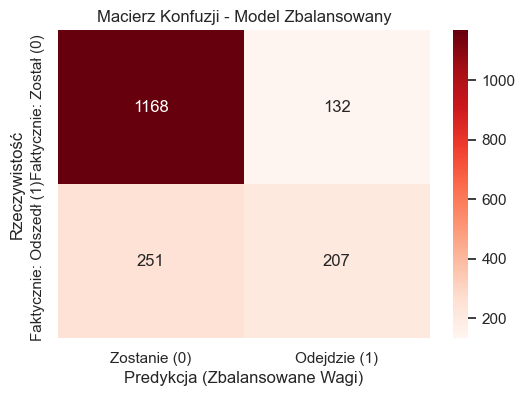

In [19]:
# Trenujemy nowy model z wyrównaniem szans dla klas
model_rf_bal = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_rf_bal.fit(X_train, y_train)

prognozy_bal = model_rf_bal.predict(X_test)

# Generujemy czerwoną macierz konfuzji dla modelu zbalansowanego
cm_bal = confusion_matrix(y_test, prognozy_bal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Zostanie (0)', 'Odejdzie (1)'], 
            yticklabels=['Faktycznie: Został (0)', 'Faktycznie: Odszedł (1)'])
plt.ylabel('Rzeczywistość')
plt.xlabel('Predykcja (Zbalansowane Wagi)')
plt.title('Macierz Konfuzji - Model Zbalansowany')
plt.show()

**Szokujący wniosek:** Próba nałożenia matematycznych wag pogorszyła czułość modelu (Recall spadł do ok. 45%). Algorytm jest "uparty" i nadal ignoruje klasę mniejszościową. Zanim przejmiemy nad nim ręczną kontrolę, sprawdźmy, czym w ogóle kieruje się przy podejmowaniu decyzji.

## 6. Kluczowe czynniki rezygnacji (Feature Importance)

C:\Users\lewan\AppData\Local\Temp\ipykernel_17752\2535557383.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ważność', y='Cecha', data=df_waznosc, palette='viridis')


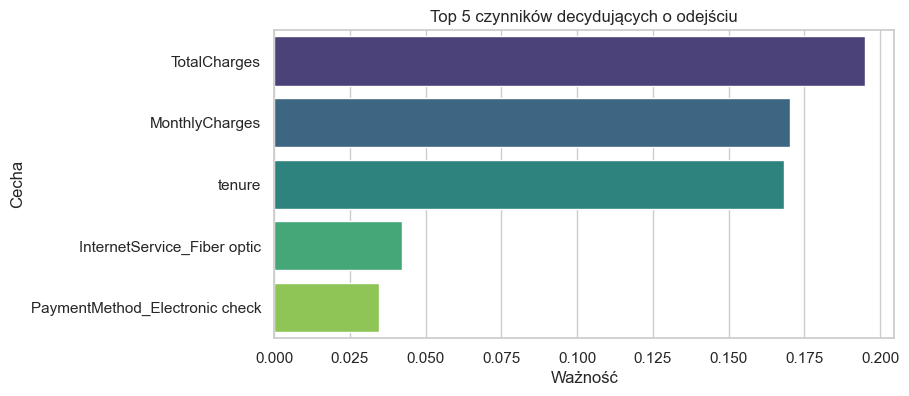

In [20]:
# Analiza ważności cech
df_waznosc = pd.DataFrame({'Cecha': X_train.columns, 'Ważność': model_rf.feature_importances_})
df_waznosc = df_waznosc.sort_values(by='Ważność', ascending=False).head(5)

plt.figure(figsize=(8, 4))
sns.barplot(x='Ważność', y='Cecha', data=df_waznosc, palette='viridis')
plt.title('Top 5 czynników decydujących o odejściu')
plt.show()

Największy wpływ na odejścia mają ewidentnie kwestie finansowe (całkowite opłaty, miesięczny rachunek) oraz staż klienta.

## 7. Optymalizacja Biznesowa: Threshold Tuning
W biznesie abonamentowym koszt zaoferowania rabatu lojalnemu klientowi (Fałszywy Alarm) jest niższy niż całkowita utrata uciekającego klienta (Przegapienie). Obniżamy próg decyzyjny z 50% na **30% prawdopodobieństwa**, aby model stał się bardziej czuły na ryzyko.

--- RAPORT PO OBNIŻENIU PROGU DO 30% ---
              precision    recall  f1-score   support

         0.0       0.89      0.74      0.80      1300
         1.0       0.50      0.74      0.59       458

    accuracy                           0.74      1758
   macro avg       0.69      0.74      0.70      1758
weighted avg       0.79      0.74      0.75      1758



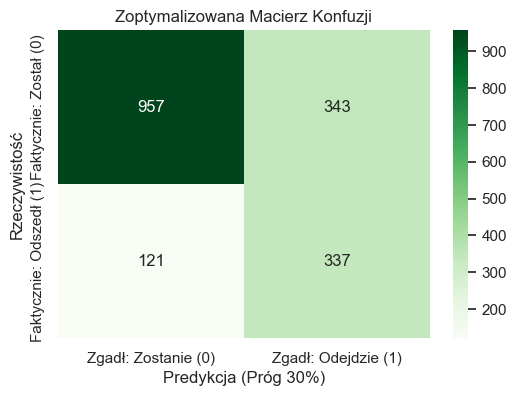

In [21]:
# Pobranie procentowych prawdopodobieństw zamiast twardych decyzji 0/1
prawdopodobienstwa = model_rf.predict_proba(X_test)[:, 1]

# Ustalenie agresywnego progu
nowy_prog = 0.30
prognozy_agresywne = (prawdopodobienstwa >= nowy_prog).astype(int)

print("--- RAPORT PO OBNIŻENIU PROGU DO 30% ---")
print(classification_report(y_test, prognozy_agresywne))

# Generujemy ostateczną, macierz konfuzji
cm_prog = confusion_matrix(y_test, prognozy_agresywne)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_prog, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Zgadł: Zostanie (0)', 'Zgadł: Odejdzie (1)'], 
            yticklabels=['Faktycznie: Został (0)', 'Faktycznie: Odszedł (1)'])
plt.ylabel('Rzeczywistość')
plt.xlabel('Predykcja (Próg 30%)')
plt.title('Zoptymalizowana Macierz Konfuzji')
plt.show()

## Podsumowanie
Dzięki ręcznej manipulacji progiem odcięcia zwiększyliśmy skuteczność wyłapywania rezygnacji (Recall) z **48% do aż 74%**. Model wyłapuje teraz zdecydowaną większość uciekających klientów (337 osób w zbiorze testowym), dostarczając zespołowi utrzymania zoptymalizowaną bazę do minimalizacji strat.